In [1]:
import os
from datetime import datetime, timedelta
import glob

from cartopy.crs import NorthPolarStereo
from cartopy.feature import LAND, COASTLINE
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np
from pysida.lib import DAY_SECONDS

In [2]:
def decorate_map(ax, map_extent, crs):
    ax.add_feature(LAND)
    ax.add_feature(COASTLINE)
    ax.set_extent(map_extent, crs=crs)

srs_dst = NorthPolarStereo(central_longitude=-45, true_scale_latitude=60)
map_extent = [-2300000, 300000, -1000000, 2000000]
titles = ['RGPS', 'BBM']


In [3]:
# EXP 01
param_names = ['compression_factor', 'C_lab', 'nu0', 'tan_phi']
imask = '../run_experiment/tru_cfg_01/sa10free_mat*cfg'

param_vals = {}
tru_cfg_files = sorted(glob.glob(imask))
for tru_cfg_file in tru_cfg_files:
    exp_num = tru_cfg_file.split('/')[-1].split('.')[0].split('_')[1].replace('mat','')
    param_vals[exp_num] = {}
    with open(tru_cfg_file) as f:
        lines = f.readlines()

    for line in lines:
        for param_name in param_names:
            if param_name in line:
                param_vals[exp_num][param_name] = float(line.strip().split('=')[1])


13 [5.0e+02 1.6e+06] [6.000e+02 1.725e+06]
37 [  20000. 1600000.] [  19000. 1575000.]
2 [ 10000. 500000.] [  8200. 525000.]
26 [  10000. 3000000.] [   9800. 2875000.]


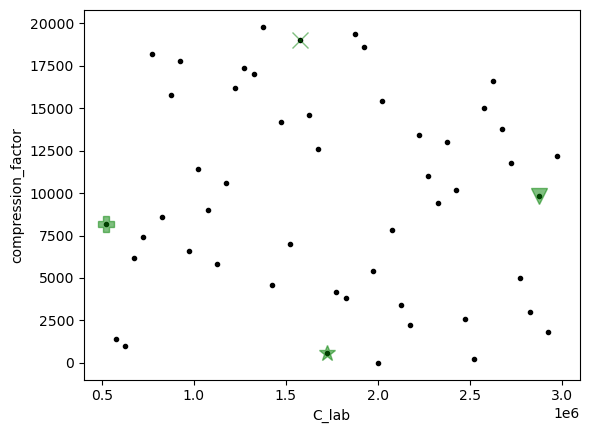

In [4]:
param_names = ['compression_factor', 'C_lab']
param_val_arr = [[param_vals[exp][param_name] for param_name in param_names] for exp in param_vals]
param_val_arr = np.array(param_val_arr)
param_val_std = np.std(param_val_arr, axis=0)#[None]
param_val_avg = np.mean(param_val_arr, axis=0)#[None]
param_val_nrm = (param_val_arr - param_val_avg) / param_val_std

best_vals_arrs = [
    np.array([   500, 1.6e6]), # lowest compression_factor
    np.array([ 20000, 1.6e6]), # highest compression_factor
    np.array([ 10000, 0.5e6]), # lowest C_lab
    np.array([ 10000, 3.0e6]), # highest C_lab
]

i = 1
plt.plot(param_val_arr.T[i], param_val_arr.T[0], 'k.')

best_param_is = []
color_index = np.arange(51)
symbols = ['*', 'x', 'P', 'v']


for best_vals_arr_idx, best_vals_arr in enumerate(best_vals_arrs):
    best_vals_nrm = (best_vals_arr - param_val_avg) / param_val_std

    best_param_i = np.argmin(np.sum((param_val_nrm - best_vals_nrm)**2, axis=1))
    best_param_is.append(best_param_i)
    print(best_param_i, best_vals_arr, param_val_arr[best_param_i])

    exp_nums = np.array([int(exp) for exp in param_vals])

    plt.plot(param_val_arr[best_param_i, i], param_val_arr[best_param_i, 0], 'g'+symbols[best_vals_arr_idx], ms=12, alpha=0.5)
    plt.xlabel(param_names[i])
plt.ylabel(param_names[0])
plt.show()


In [5]:
idir = '../music_matrix/cfg01_m20'
best_param_is_4use = list(best_param_is)
pfiles = [f'{idir}/mat{best_param_i:02}_pairs.npz' for best_param_i in best_param_is_4use]
sources = ['neXtSIM'] * len(pfiles)

pfiles += ['../rgps_csv/w07_may_pairs.npz']
sources += ['RGPS']
force = True

plot_dates = [datetime(2007,1,25), datetime(2007,2, 3), datetime(2007,2, 15)]
print(len(pfiles), len(sources), len(plot_dates))

5 5 3


In [6]:
pairs_all = {}
defor_all = {}
for ipfile, (pfile, src) in enumerate(zip(pfiles, sources)):
    dfile = pfile.replace('_pairs.npz', '_defor.npz')
    pairs_all[pfile] = np.load(pfile, allow_pickle=True)['pairs']
    defor_all[pfile] = np.load(dfile, allow_pickle=True)['defor']


In [7]:
column_titles = ['Low $P_0$', 'High $P_0$', 'Low $c_{ref}$', 'High $c_{ref}$', 'RGPS']
period_len = timedelta(4)

fig, axs = plt.subplots(3, 5, figsize=(15, 11), subplot_kw={'projection': srs_dst})
for ipfile, (pfile, src) in enumerate(zip(pfiles, sources)):
    pairs = pairs_all[pfile]
    defor = defor_all[pfile]
    for idate, date1 in enumerate(plot_dates):
        date_str = date1.strftime('%Y-%m-%d')
        print(pfile, date1)
        for p, d in zip(pairs, defor):
            if p is None or d is None:
                continue
            if date1 <= p.d1 < (date1 + period_len):
                e = np.hypot(d.e1, d.e2) * DAY_SECONDS
                trp = axs[idate, ipfile].tripcolor(p.x1, p.y1, e, triangles=p.t, vmin=0, vmax=0.1, cmap='plasma_r', mask=~p.g)
    axs[0, ipfile].set_title(column_titles[ipfile], fontsize=20)

for idate, date1 in enumerate(plot_dates):
    date_str = date1.strftime('%Y-%m-%d')
    axs[idate, 0].text(
        -2100000, 500000, date_str,
        fontsize=20,
        bbox = dict(facecolor = 'white', edgecolor='white', alpha = 0.85),
        rotation=90)

for ax in axs.flat:
    decorate_map(ax, map_extent, srs_dst)

plt.tight_layout(h_pad=0, w_pad=0)

cbar_ax = fig.add_axes([0.1,0.0,0.8,0.03])
cbar = fig.colorbar(trp, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Total deformation, 1/d', fontsize=20)
cbar.ax.tick_params(labelsize=20)

ofile = '../tuning_paper_figures/fig00_maps_rgps_nextsim.png'
plt.savefig(ofile, dpi=150, bbox_inches='tight', pad_inches=0)
plt.close()
print(ofile)


../music_matrix/cfg01_m20/mat13_pairs.npz 2007-01-25 00:00:00
../music_matrix/cfg01_m20/mat13_pairs.npz 2007-02-03 00:00:00
../music_matrix/cfg01_m20/mat13_pairs.npz 2007-02-15 00:00:00
../music_matrix/cfg01_m20/mat37_pairs.npz 2007-01-25 00:00:00
../music_matrix/cfg01_m20/mat37_pairs.npz 2007-02-03 00:00:00
../music_matrix/cfg01_m20/mat37_pairs.npz 2007-02-15 00:00:00
../music_matrix/cfg01_m20/mat02_pairs.npz 2007-01-25 00:00:00
../music_matrix/cfg01_m20/mat02_pairs.npz 2007-02-03 00:00:00
../music_matrix/cfg01_m20/mat02_pairs.npz 2007-02-15 00:00:00
../music_matrix/cfg01_m20/mat26_pairs.npz 2007-01-25 00:00:00
../music_matrix/cfg01_m20/mat26_pairs.npz 2007-02-03 00:00:00
../music_matrix/cfg01_m20/mat26_pairs.npz 2007-02-15 00:00:00
../rgps_csv/w07_may_pairs.npz 2007-01-25 00:00:00
../rgps_csv/w07_may_pairs.npz 2007-02-03 00:00:00
../rgps_csv/w07_may_pairs.npz 2007-02-15 00:00:00
../tuning_paper_figures/fig00_maps_rgps_nextsim.png
